In [14]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import equinox as eqx
import diffrax
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import random

In [ ]:
spirals = jnp.load("spirals.npz")

data_train = spirals["xy_train"]
data_test = spirals["xy_test"]
alpha_train = spirals["alpha_train"]

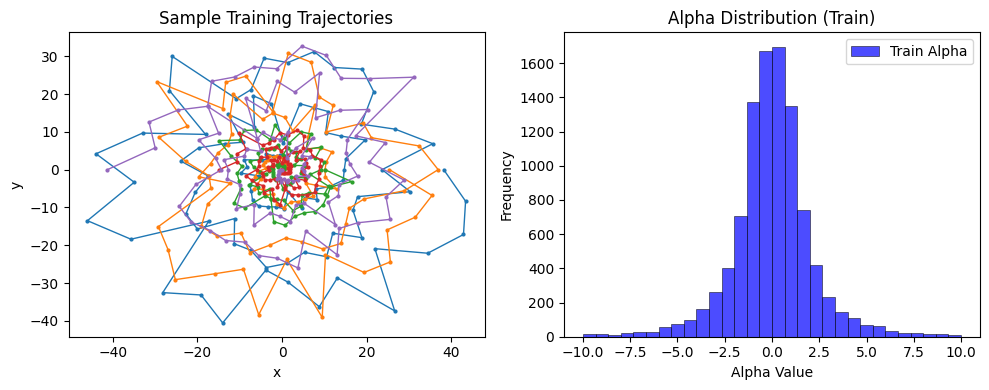

In [43]:
# plot trajectories (70%) and alpha histogram (30%) side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [5, 5]})

# left: sample 10 random training trajectories
for _ in range(5):
    rand_idx = random.randint(0, data_train.shape[0] - 1)
    axes[0].plot(data_train[rand_idx, :, 0], data_train[rand_idx, :, 1], marker='o', markersize=2, linewidth=1)
axes[0].set_title('Sample Training Trajectories')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# right: alpha distribution
axes[1].hist(alpha_train.ravel(), bins=30, alpha=0.7, label='Train Alpha', color='blue', range=(-10, 10), edgecolor='black', linewidth=0.5)
axes[1].set_title('Alpha Distribution (Train)')
axes[1].set_xlabel('Alpha Value')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
# save
plt.savefig('trajectories_and_alpha_distribution.png')
plt.show()